In [1]:
print("Hello World")

Hello World


In [3]:
# Task Structure
# 1. Introduction
# 2. Import Libraries
# 3. Load Dataset
# 4. Data Exploration
# 5. Data Visualization
# 6. Data Preprocessing
# 7. Train-Test Split
# 8. Linear Regression Model
# 9. Prediction
# 10. Evaluation
# 11. Conclusion
# 12. Save Model

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [5]:
# Load California Housing Dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['HousePrice'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

df.describe()

Shape of Dataset: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check Missing Values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

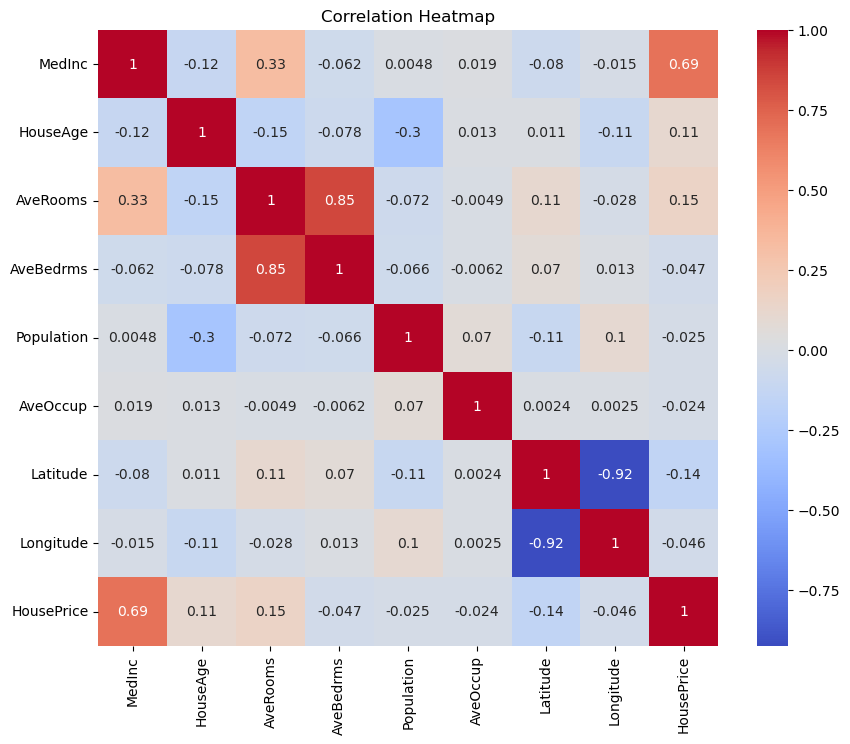

In [8]:
# Exploratory Data Analysis (EDA)
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

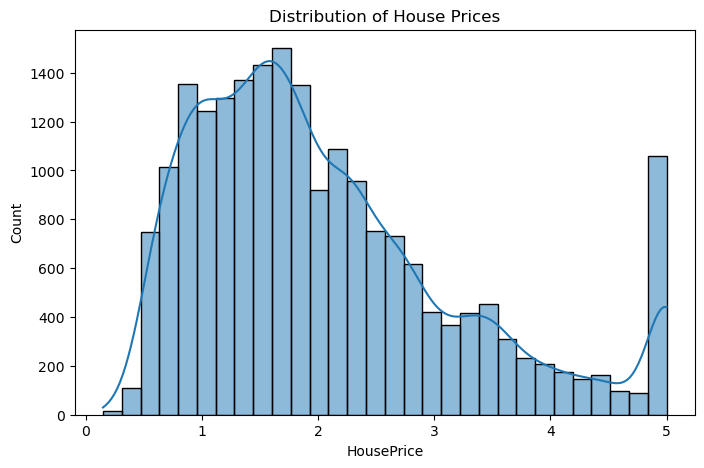

In [9]:
# House Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['HousePrice'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

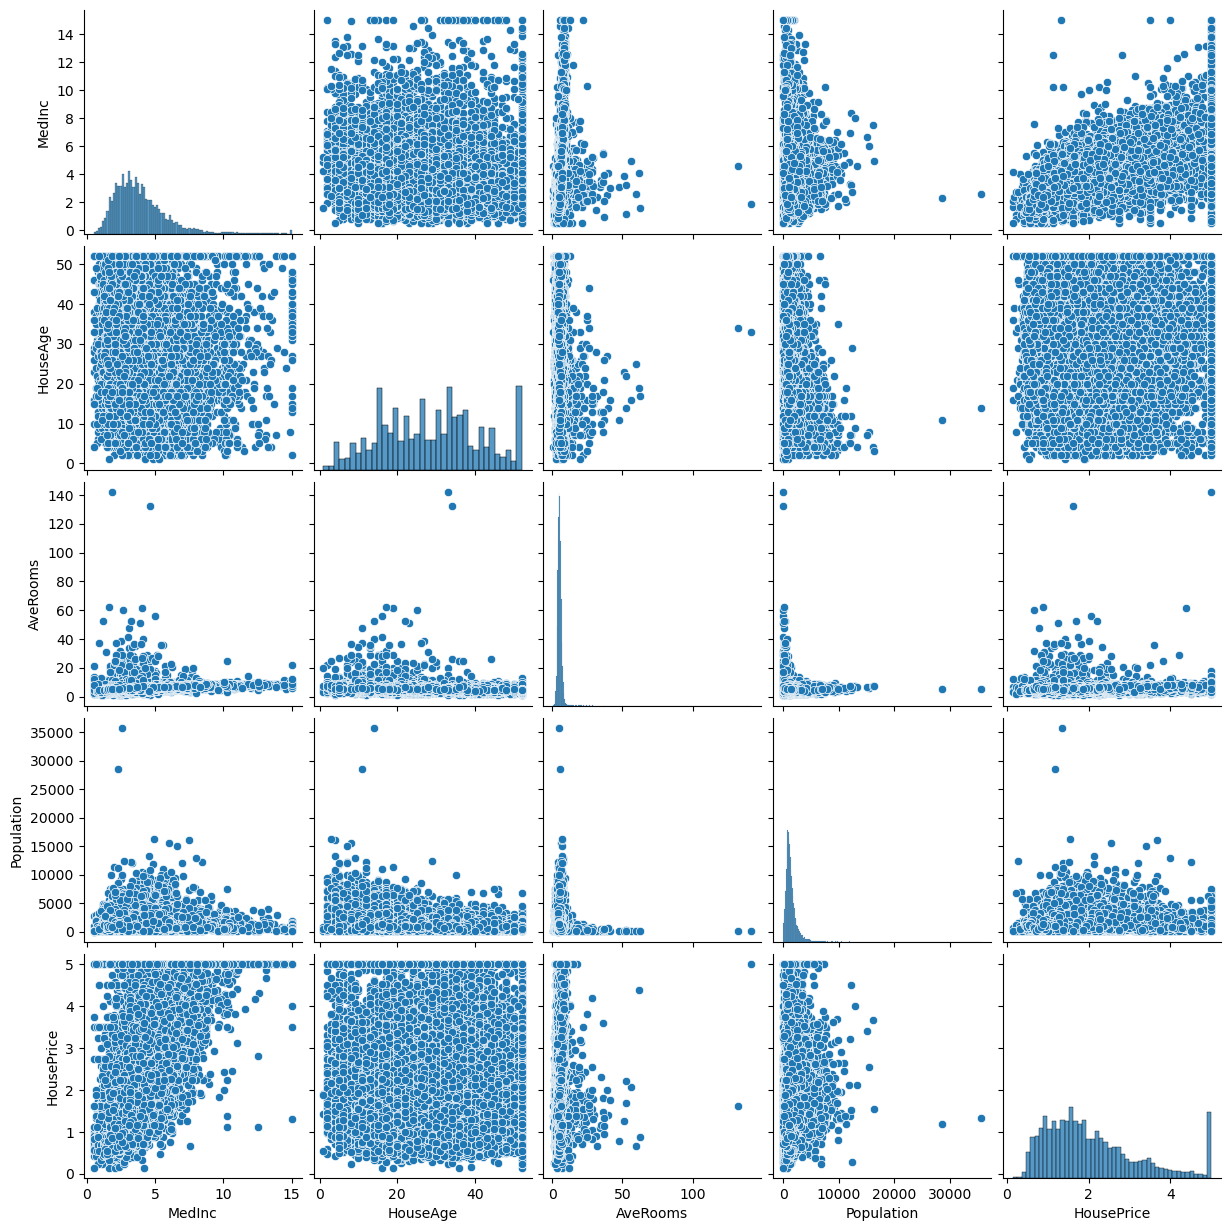

In [10]:
# Pairplot
sns.pairplot(
    df[['MedInc','HouseAge','AveRooms','Population','HousePrice']]
)
plt.show()

In [11]:
# Define Features and Target
X = df.drop('HousePrice', axis=1)

y = df['HousePrice']

In [12]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (16512, 8)
Testing Samples: (4128, 8)


In [13]:
# Train Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [15]:
# Make Predictions
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [16]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.5332001304956557
RMSE: 0.7455813830127762
R² Score: 0.575787706032451


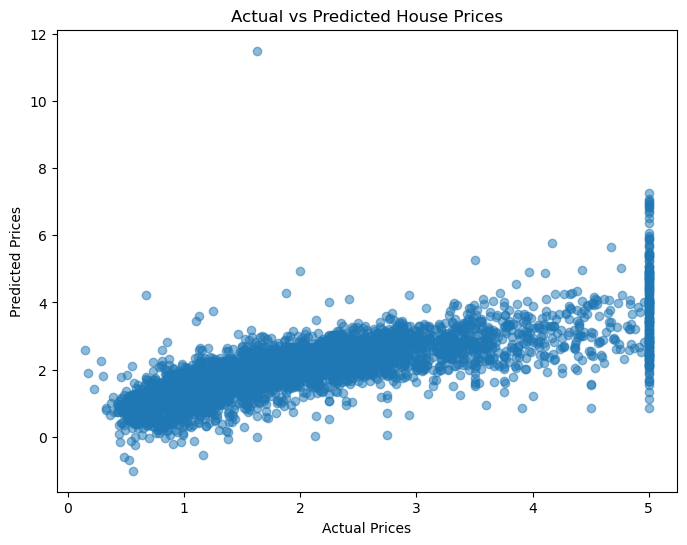

In [17]:
# Actual vs Predicted Visualization
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [18]:
# Feature Importance (Coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [19]:
# Save Model
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [20]:
# Load Saved Model
with open("house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Saved Model Loaded!")

Saved Model Loaded!


In [21]:
# Predict on New Data
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 4.1519426857529425


DATASET OVERVIEW
Shape: (20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.0

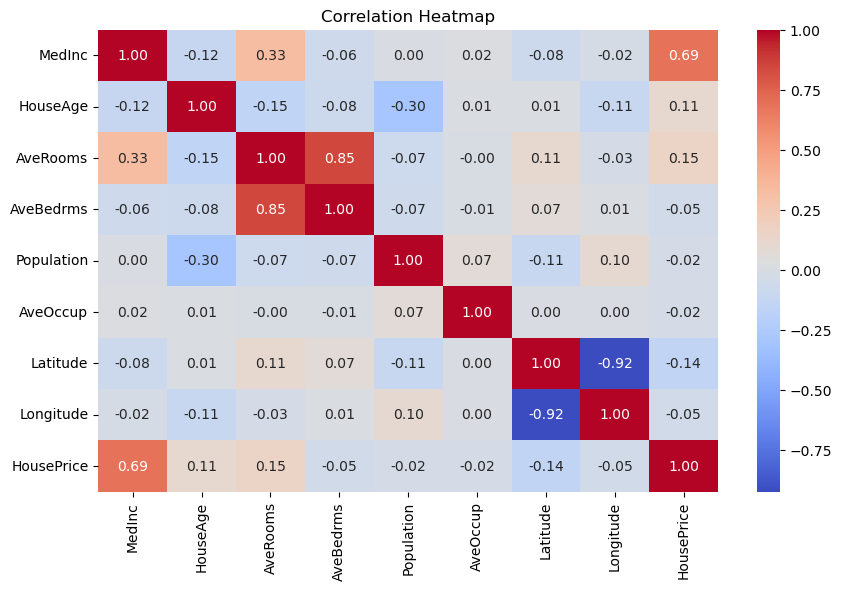

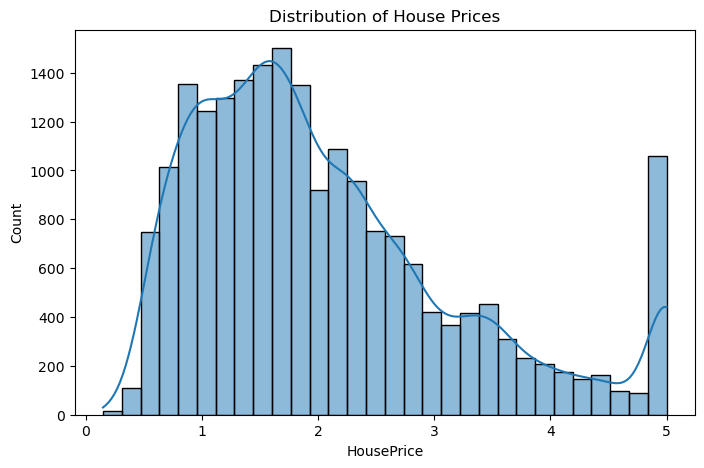

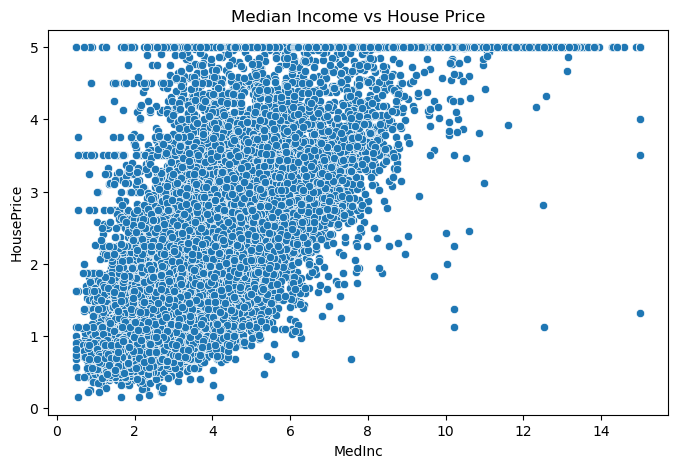


Training Shape: (16512, 8)
Testing Shape: (4128, 8)

Model Training Completed Successfully!

MODEL PERFORMANCE
Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


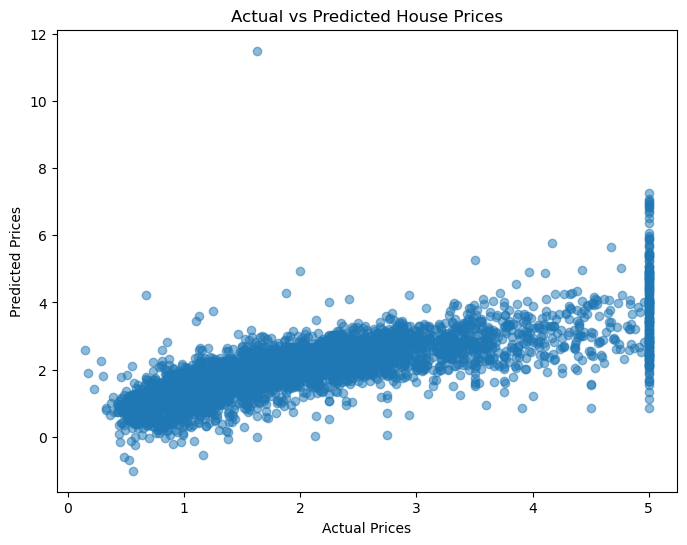


Feature Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708

Model saved as 'house_price_model.pkl'

Sample Prediction: 4.1519426857529425

Project Completed Successfully!


In [22]:
# FULL PROGRAM 

# ============================
# HOUSE PRICE PREDICTION USING LINEAR REGRESSION
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# ----------------------------
# Load Dataset
# ----------------------------
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['HousePrice'] = housing.target

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ----------------------------
# Exploratory Data Analysis
# ----------------------------

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['HousePrice'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['MedInc'], y=df['HousePrice'])
plt.title("Median Income vs House Price")
plt.show()

# ----------------------------
# Feature Selection
# ----------------------------
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

# ----------------------------
# Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ----------------------------
# Model Training
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")

# ----------------------------
# Prediction
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# Evaluation
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))

# ----------------------------
# Actual vs Predicted
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# ----------------------------
# Feature Importance
# ----------------------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# ----------------------------
# Save Model
# ----------------------------
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel saved as 'house_price_model.pkl'")

# ----------------------------
# Test Saved Model
# ----------------------------
with open("house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

sample = X.iloc[[0]]
prediction = loaded_model.predict(sample)

print("\nSample Prediction:", prediction[0])

print("\nProject Completed Successfully!")